<a href="https://colab.research.google.com/github/erdijova/Practical-Linear-Algebra-for-Data-Science/blob/main/15_Eigendecomposition_and_SVD_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### PCA Using Eigendecomposition and SVD

The purpose of PCA is to find a set of basis vectors for a dataset that point in the
direction that maximizes covariation across the variables.
Imagine that an N-D dataset exists in an N-D space, with each data point being a
coordinate in that space. This is sensible when you think about storing the data in a
matrix with N observations (each row is an observation) of M features (each column
is a feature, also called variable or measurement); the data live in R

M and comprise N

vectors or coordinates.

In [5]:
# Setup: Import required libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh   # for symmetric & generalized eigendecomp
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True, linewidth=120)

print("Libraries loaded successfully.")
print(f"NumPy version: {np.__version__}")

Libraries loaded successfully.
NumPy version: 2.0.2


Original data shape: (300, 2)
Covariance matrix:
[[4.1051 2.5737]
 [2.5737 2.4867]]

Eigenvalues: [5.9939 0.5979]
  PC1 captures 90.9% of variance
  PC2 captures 9.1% of variance

Eigenvectors (principal directions):
  PC1 direction: [-0.8062 -0.5916]
  PC2 direction: [ 0.5916 -0.8062]
  Orthogonal? dot product = 0.00e+00


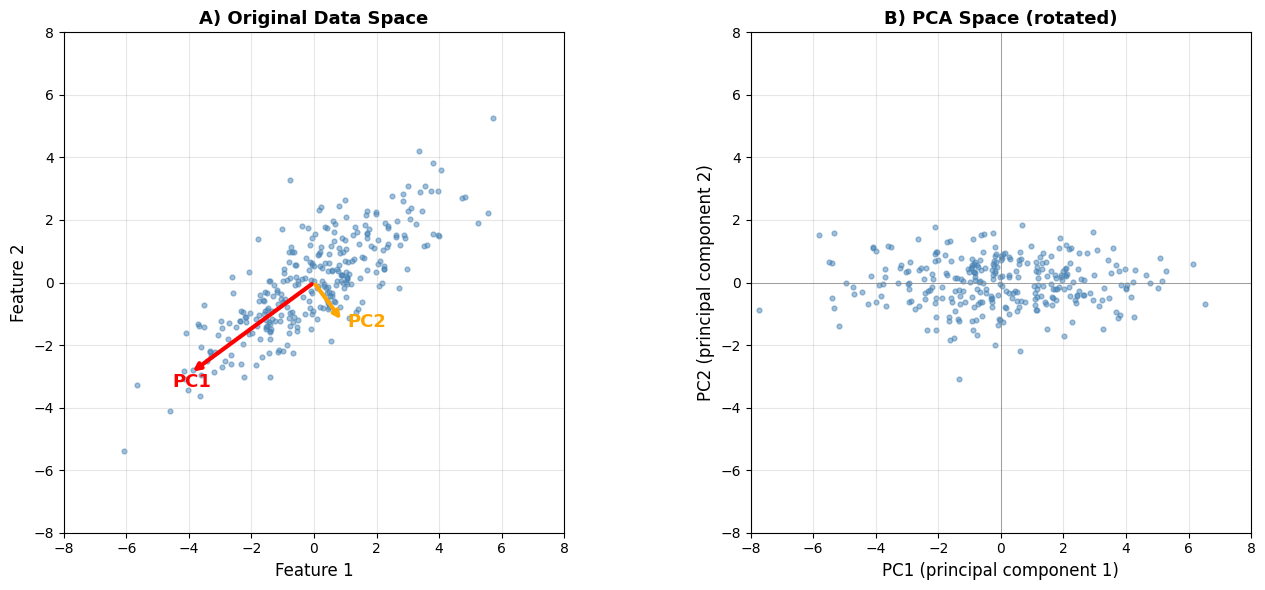

Figure 15-1: PCA rotates data to align with directions of maximum variance.


In [6]:
# Figure 15-1: PCA in 2D -- Before and After

np.random.seed(42)

# Generate correlated 2D data
n = 300
# Correlation structure: axis 1 and axis 2 are positively correlated
theta = np.pi / 5  # rotation angle (~36 degrees)
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
raw = np.random.randn(n, 2) @ np.diag([2.5, 0.8])  # stretch along one axis
data_2d = raw @ R.T  # rotate to create correlation

# Mean-center the data (CRITICAL step for PCA!)
data_centered = data_2d - data_2d.mean(axis=0)

# Compute covariance matrix and its eigendecomposition
C = data_centered.T @ data_centered / (n - 1)
evals, evecs = np.linalg.eigh(C)

# Sort descending (eigh returns ascending)
sort_idx = np.argsort(evals)[::-1]
evals = evals[sort_idx]
evecs = evecs[:, sort_idx]

# Project data onto principal components
scores = data_centered @ evecs  # "component scores"

print(f"Original data shape: {data_2d.shape}")
print(f"Covariance matrix:\n{C.round(4)}")
print(f"\nEigenvalues: {evals.round(4)}")
print(f"  PC1 captures {evals[0]/evals.sum()*100:.1f}% of variance")
print(f"  PC2 captures {evals[1]/evals.sum()*100:.1f}% of variance")
print(f"\nEigenvectors (principal directions):")
print(f"  PC1 direction: {evecs[:,0].round(4)}")
print(f"  PC2 direction: {evecs[:,1].round(4)}")
print(f"  Orthogonal? dot product = {np.dot(evecs[:,0], evecs[:,1]):.2e}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A: Original data space
ax = axes[0]
ax.scatter(data_centered[:, 0], data_centered[:, 1], s=12, alpha=0.5, c='steelblue')
# Draw eigenvectors (scaled by eigenvalue for visibility)
origin = [0, 0]
for i, (ev, col, lbl) in enumerate(zip([0, 1], ['red', 'orange'],
                                        ['PC1', 'PC2'])):
    scale = np.sqrt(evals[ev]) * 2
    ax.annotate('', xy=evecs[:, ev]*scale, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=col, lw=3))
    ax.text(evecs[0, ev]*scale*1.15, evecs[1, ev]*scale*1.15, lbl,
            fontsize=13, fontweight='bold', color=col)
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('A) Original Data Space', fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)

# Panel B: PCA space
ax = axes[1]
ax.scatter(scores[:, 0], scores[:, 1], s=12, alpha=0.5, c='steelblue')
ax.set_xlabel('PC1 (principal component 1)', fontsize=12)
ax.set_ylabel('PC2 (principal component 2)', fontsize=12)
ax.set_title('B) PCA Space (rotated)', fontsize=13, fontweight='bold')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.show()
print("Figure 15-1: PCA rotates data to align with directions of maximum variance.")

**Interpreting the PCA Results**

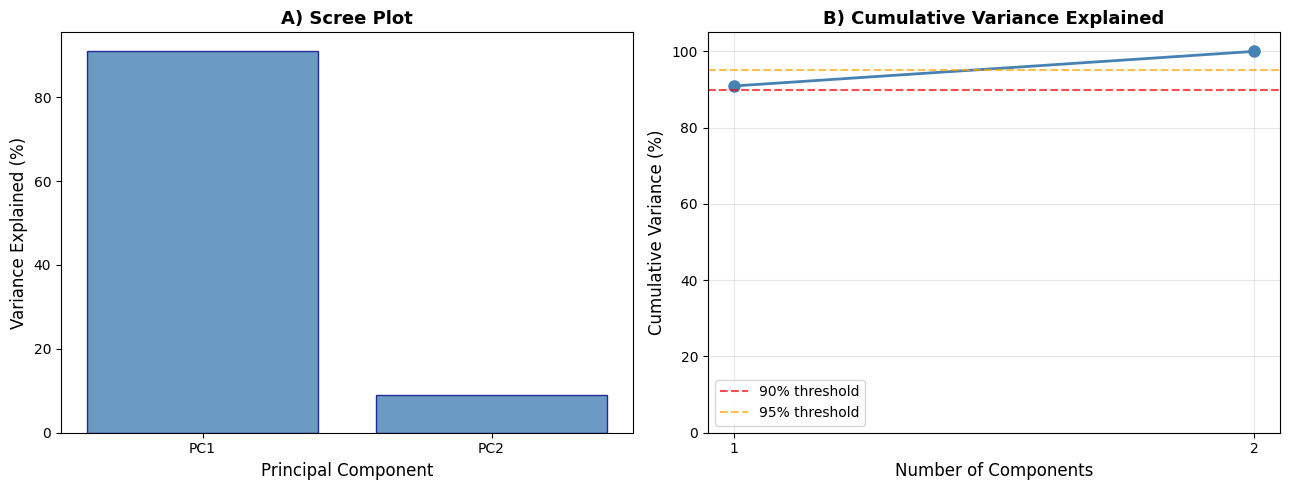

The scree plot helps decide how many components to retain.


In [8]:
import numpy as np

# Scree plot and cumulative variance

# Define M, pct_var, and cum_var from the 'evals' array
M = len(evals)
pct_var = (evals / evals.sum()) * 100
cum_var = np.cumsum(pct_var)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: Scree plot
axes[0].bar(range(1, M+1), pct_var, color='steelblue', edgecolor='navy', alpha=0.8)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained (%)', fontsize=12)
axes[0].set_title('A) Scree Plot', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, M+1))
axes[0].set_xticklabels([f'PC{i}' for i in range(1, M+1)])

# Panel B: Cumulative variance
axes[1].plot(range(1, M+1), cum_var, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].axhline(90, color='red', linestyle='--', alpha=0.7, label='90% threshold')
axes[1].axhline(95, color='orange', linestyle='--', alpha=0.7, label='95% threshold')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance (%)', fontsize=12)
axes[1].set_title('B) Cumulative Variance Explained', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, M+1))
axes[1].set_ylim(0, 105)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("The scree plot helps decide how many components to retain.")

**How Many Components to Keep? The Scree Plot**

The scree plot (left) shows the eigenvalue (variance) for each component. Look for the "elbow" -- the point where the bars drop sharply. In our data, the elbow is clearly after PC2: the first two components have large eigenvalues, and the remaining two are nearly flat and close to zero.

In [10]:
# PCA via SVD (two methods)

# Method 1: SVD of the covariance matrix
U_cov, S_cov, Vt_cov = np.linalg.svd(C)

print("Method 1: SVD of the covariance matrix C = X^T X / (n-1)")
print(f"  Singular values of C: {S_cov.round(4)}")
print(f"  Eigenvalues of C:     {evals.round(4)}")
print(f"  Match? {np.allclose(sorted(S_cov, reverse=True), sorted(evals, reverse=True))}")
print(f"  (For symmetric PSD matrices, singular values = eigenvalues)")

# Method 2: SVD of the data matrix directly
U_data, S_data, Vt_data = np.linalg.svd(data_centered, full_matrices=False)

# The right singular vectors V are the principal directions
# The singular values relate to eigenvalues: evals = sigma^2 / (N-1)
evals_from_svd = S_data**2 / (n - 1)

print(f"\nMethod 2: SVD of the data matrix X directly")
print(f"  Singular values of X: {S_data.round(4)}")
print(f"  sigma^2 / (N-1):      {evals_from_svd.round(4)}")
print(f"  Eigenvalues of C:     {evals.round(4)}")
print(f"  Match? {np.allclose(sorted(evals_from_svd, reverse=True), sorted(evals, reverse=True))}")

# Component scores from SVD: X @ V = U @ Sigma
scores_svd = data_centered @ Vt_data.T  # or equivalently: U_data * S_data
scores_eig = data_centered @ evecs

# Check they match (up to sign flips)
for i in range(M):
    corr = np.corrcoef(np.abs(scores_eig[:, i]), np.abs(scores_svd[:, i]))[0, 1]
    print(f"  PC{i+1}: correlation between eig and SVD scores = {corr:.6f}")

Method 1: SVD of the covariance matrix C = X^T X / (n-1)
  Singular values of C: [5.9939 0.5979]
  Eigenvalues of C:     [5.9939 0.5979]
  Match? True
  (For symmetric PSD matrices, singular values = eigenvalues)

Method 2: SVD of the data matrix X directly
  Singular values of X: [42.3339 13.3709]
  sigma^2 / (N-1):      [5.9939 0.5979]
  Eigenvalues of C:     [5.9939 0.5979]
  Match? True
  PC1: correlation between eig and SVD scores = 1.000000
  PC2: correlation between eig and SVD scores = 1.000000


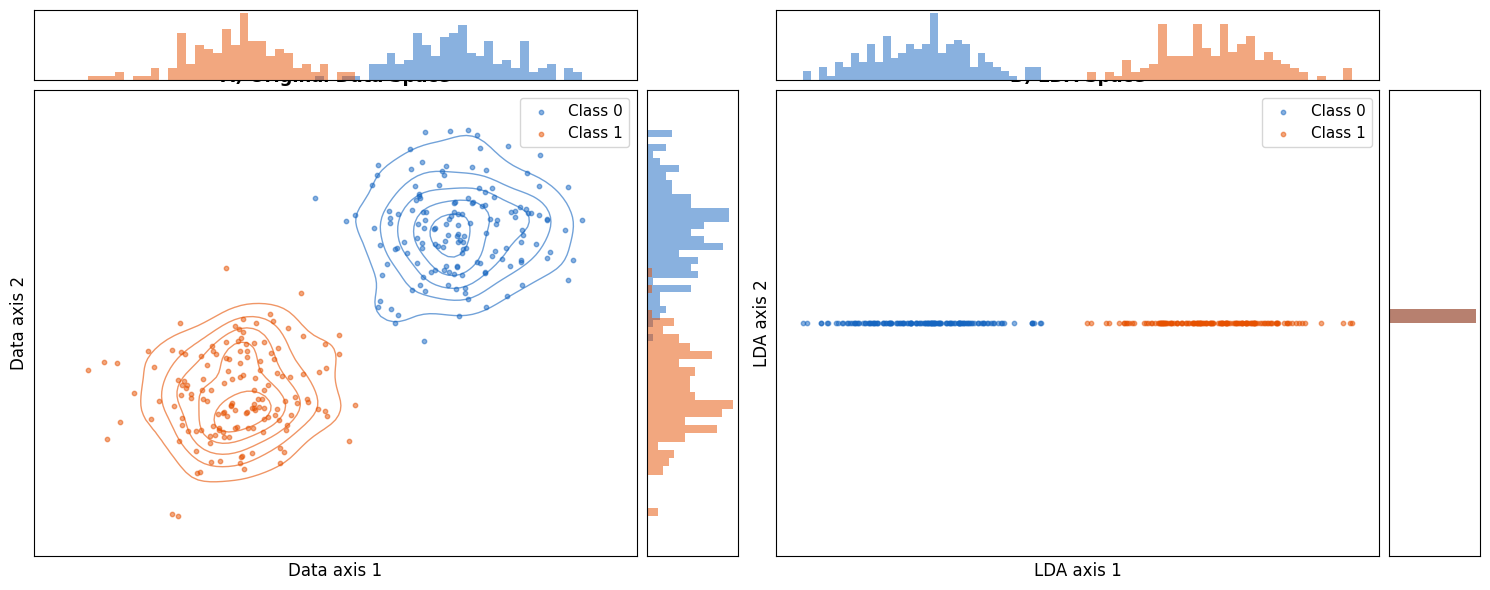

Classification accuracy using LDA axis 1 (threshold = 0): 100.0%


In [13]:
# Figure 15-2: Original data vs LDA-projected data

import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from matplotlib.colors import ListedColormap

# Generate synthetic data for LDA (two classes)
n_samples = 300
X = np.concatenate([np.random.randn(n_samples // 2, 2) + np.array([2, 2]),
                    np.random.randn(n_samples // 2, 2) + np.array([-2, -2])])
y = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2))

# Assign to X_lda and y_lda as expected by the plotting code
X_lda = X
y_lda = y

# Perform LDA
lda = LinearDiscriminantAnalysis(n_components=1) # For 2 classes, max components is 1
scores_lda = lda.fit_transform(X, y)

# If scores_lda is 1D, make it 2D for consistent indexing
if scores_lda.ndim == 1:
    scores_lda = scores_lda.reshape(-1, 1)

# Expand scores_lda to 2D for plotting, filling the second dimension with zeros
# This is a common practice when visualizing 1-component LDA results in 2D plots
scores_lda_full = np.zeros((scores_lda.shape[0], 2))
scores_lda_full[:, 0] = scores_lda.flatten() # Put the single LDA component in the first axis
scores_lda = scores_lda_full

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Custom colors
colors = ['#1565C0', '#E65100']  # blue, orange

# --- Panel A: Original data space ---
ax = axes[0]
for cls, color, label in [(0, colors[0], 'Class 0'), (1, colors[1], 'Class 1')]:
    mask = y_lda == cls
    ax.scatter(X_lda[mask, 0], X_lda[mask, 1], s=10, alpha=0.5, c=color, label=label)
    # Add contour
    from scipy.stats import gaussian_kde
    xy = X_lda[mask].T
    kde = gaussian_kde(xy)
    xg = np.linspace(X_lda[:, 0].min()-1, X_lda[:, 0].max()+1, 100)
    yg = np.linspace(X_lda[:, 1].min()-1, X_lda[:, 1].max()+1, 100)
    Xg, Yg = np.meshgrid(xg, yg)
    Z = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)
    ax.contour(Xg, Yg, Z, levels=5, colors=color, alpha=0.6, linewidths=1)

ax.set_xlabel('Data axis 1', fontsize=12)
ax.set_ylabel('Data axis 2', fontsize=12)
ax.set_title('A) Original Data Space', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

# Marginal distributions on top and right
# (simplified version without seaborn)
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
ax_top = divider.append_axes("top", size="15%", pad=0.1, sharex=ax)
ax_right = divider.append_axes("right", size="15%", pad=0.1, sharey=ax)

for cls, color in [(0, colors[0]), (1, colors[1])]:
    mask = y_lda == cls
    ax_top.hist(X_lda[mask, 0], bins=30, alpha=0.5, color=color, density=True)
    ax_right.hist(X_lda[mask, 1], bins=30, alpha=0.5, color=color, density=True,
                  orientation='horizontal')
ax_top.set_yticks([])
ax_top.set_xticks([])
ax_right.set_xticks([])
ax_right.set_yticks([])

# --- Panel B: LDA space ---
ax = axes[1]
for cls, color, label in [(0, colors[0], 'Class 0'), (1, colors[1], 'Class 1')]:
    mask = y_lda == cls
    ax.scatter(scores_lda[mask, 0], scores_lda[mask, 1], s=10, alpha=0.5, c=color, label=label)
    # Removed kde plotting for 1D LDA data

ax.set_xlabel('LDA axis 1', fontsize=12)
ax.set_ylabel('LDA axis 2', fontsize=12)
ax.set_title('B) LDA Space', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.2)

divider2 = make_axes_locatable(ax)
ax_top2 = divider2.append_axes("top", size="15%", pad=0.1, sharex=ax)
ax_right2 = divider2.append_axes("right", size="15%", pad=0.1, sharey=ax)

for cls, color in [(0, colors[0]), (1, colors[1])]:
    mask = y_lda == cls
    ax_top2.hist(scores_lda[mask, 0], bins=30, alpha=0.5, color=color, density=True)
    ax_right2.hist(scores_lda[mask, 1], bins=30, alpha=0.5, color=color, density=True,
                   orientation='horizontal')
ax_top2.set_yticks([])
ax_top2.set_xticks([])
ax_right2.set_xticks([])
ax_right2.set_yticks([])

plt.tight_layout()
plt.show()

# Classification accuracy on LDA axis 1
threshold = 0  # simple threshold at 0
pred = (scores_lda[:, 0] > threshold).astype(int)
accuracy = np.mean(pred == y_lda) * 100
print(f"Classification accuracy using LDA axis 1 (threshold = 0): {accuracy:.1f}%")

**The Math of PCA**

PCA combines the statistical concept of variance with the linear algebra concept of
linear weighted combination. Variance, as you know, is a measure of the dispersion of
a dataset around its average value. PCA makes the assumption that variance is good,
and directions in the data space that have more variance are more important (a.k.a.
“variance = relevance”).
But in PCA, we’re not just interested in the variance within one variable; instead, we
want to find the linear weighted combination across all variables that maximizes var‐
iance of that component (a component is a linear weighted combination of variables).

**The Steps to Perform a PCA**

With the math out of the way, here are the steps to implement a PCA:2
1. Compute the covariance matrix of the data. The resulting covariance matrix will
be features-by-features. Each feature in the data must be mean-centered prior to
computing covariance.
2. Take the eigendecomposition of that covariance matrix.
3. Sort the eigenvalues descending by magnitude, and sort the eigenvectors accord‐
ingly. Eigenvalues of the PCA are sometimes called latent factor scores.
4. Compute the “component scores” as the weighted combination of all data fea‐
tures, where the eigenvector provides the weights. The eigenvector associated
with the largest eigenvalue is the “most important” component, meaning the one
with the largest variance.
5. Convert the eigenvalues to percent variance explained to facilitate interpretation.

**Linear Discriminant Analysis**

Linear discriminant analysis (LDA) is a multivariate classification technique that is
often used in machine learning and statistics. It was initially developed by Ronald
Fisher,3
who is often considered the “grandfather” of statistics for his numerous and
important contributions to the mathematical foundations of statistics.
The goal of LDA is to find a direction in the data space that maximally separates
categories of data. An example problem dataset is shown in graph A in Figure 15-2.
It is visually obvious that the two categories are separable, but they are not separable
on either of the data axes alone—that is clear from visual inspection of the marginal
distributions.
Enter LDA. LDA will find basis vectors in the data space that maximally separate
the two categories. Graph B in Figure 15-2 shows the same data but in the LDA
space. Now the classification is simple—observations with negative values on axis-1
are labeled category “0” and any observations with positive values on axis 1 are
labeled category “1.” The data is completely inseparable on axis 2, indicating that one
dimension is sufficient for accurate categorization in this dataset.

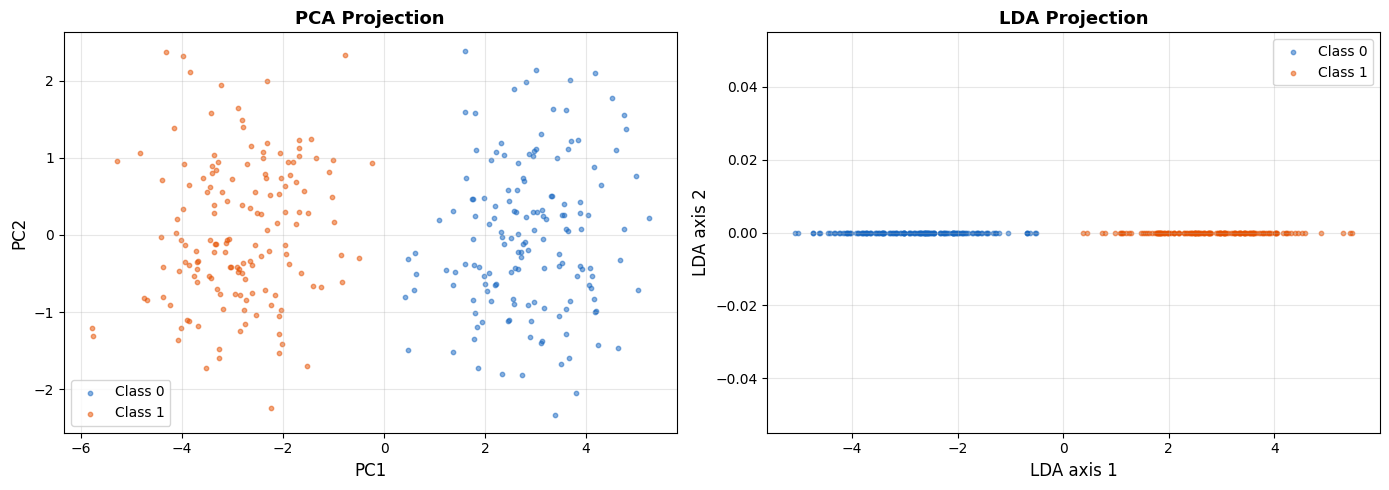

Classification accuracy using first axis:
  PCA (PC1 > 0):       0.0%
  LDA (LDA axis 1 > 0): 100.0%

PCA maximizes variance (ignores labels).
LDA maximizes class separation (uses labels).


In [14]:
# PCA vs LDA: Different objectives, different results

# Apply PCA to the same LDA dataset
X_lda_centered = X_lda - X_lda.mean(axis=0)
C_total = np.cov(X_lda_centered, rowvar=False)
evals_pca_lda, evecs_pca_lda = np.linalg.eigh(C_total)
si = np.argsort(evals_pca_lda)[::-1]
evecs_pca_lda = evecs_pca_lda[:, si]

scores_pca_lda = X_lda_centered @ evecs_pca_lda

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA projection
ax = axes[0]
for cls, color, label in [(0, '#1565C0', 'Class 0'), (1, '#E65100', 'Class 1')]:
    mask = y_lda == cls
    ax.scatter(scores_pca_lda[mask, 0], scores_pca_lda[mask, 1], s=10, alpha=0.5, c=color, label=label)
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA Projection', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# LDA projection
ax = axes[1]
for cls, color, label in [(0, '#1565C0', 'Class 0'), (1, '#E65100', 'Class 1')]:
    mask = y_lda == cls
    ax.scatter(scores_lda[mask, 0], scores_lda[mask, 1], s=10, alpha=0.5, c=color, label=label)
ax.set_xlabel('LDA axis 1', fontsize=12)
ax.set_ylabel('LDA axis 2', fontsize=12)
ax.set_title('LDA Projection', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compare classification on first axis
pred_pca = (scores_pca_lda[:, 0] > 0).astype(int)
acc_pca = np.mean(pred_pca == y_lda) * 100
pred_lda = (scores_lda[:, 0] > 0).astype(int)
acc_lda = np.mean(pred_lda == y_lda) * 100

print(f"Classification accuracy using first axis:")
print(f"  PCA (PC1 > 0):       {acc_pca:.1f}%")
print(f"  LDA (LDA axis 1 > 0): {acc_lda:.1f}%")
print(f"\nPCA maximizes variance (ignores labels).")
print(f"LDA maximizes class separation (uses labels).")

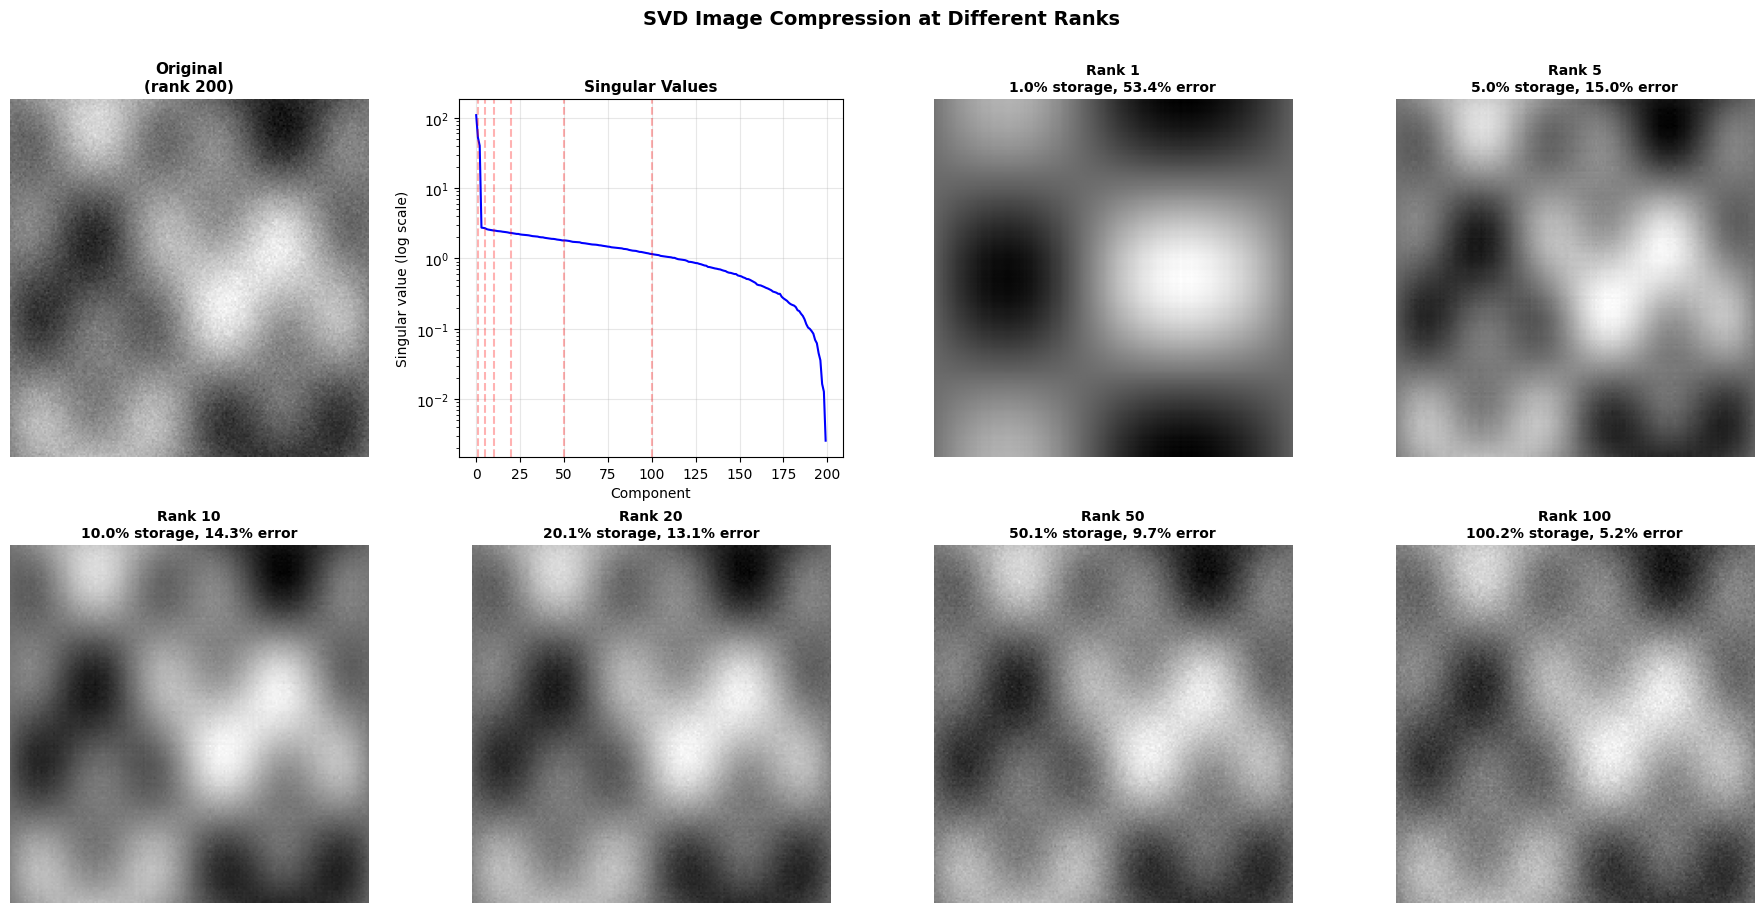


Rank k    Storage (%)   Relative Error (%)   Visual Quality
k = 1             1.0%                53.4%           Blocky
k = 5             5.0%                15.0%           Blocky
k = 10           10.0%                14.3%             Good
k = 20           20.1%                13.1%             Good
k = 50           50.1%                 9.7%        Excellent
k = 100         100.2%                 5.2%        Excellent


In [15]:
# SVD Image Compression: Visual demonstration

np.random.seed(42)

# Create a synthetic "image" with structure (gradient + circles)
m_img, n_img = 200, 200
x_grid = np.linspace(-3, 3, n_img)
y_grid = np.linspace(-3, 3, m_img)
Xg, Yg = np.meshgrid(x_grid, y_grid)

# Image: combination of patterns
img = (np.sin(Xg) * np.cos(Yg) +
       np.exp(-(Xg**2 + Yg**2)/2) +
       0.5 * np.sin(3*Xg) * np.sin(2*Yg) +
       0.1 * np.random.randn(m_img, n_img))  # small noise

# SVD of the image
U_img, S_img, Vt_img = np.linalg.svd(img, full_matrices=False)

# Reconstruct with different ranks
ranks = [1, 5, 10, 20, 50, 100]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Original
axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title(f'Original\n(rank {np.linalg.matrix_rank(img)})', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

# Singular values plot
axes[0, 1].semilogy(S_img, 'b-', linewidth=1.5)
axes[0, 1].set_xlabel('Component', fontsize=10)
axes[0, 1].set_ylabel('Singular value (log scale)', fontsize=10)
axes[0, 1].set_title('Singular Values', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
for k in ranks:
    axes[0, 1].axvline(k, color='red', linestyle='--', alpha=0.3)

# Reconstructions
for idx, k in enumerate(ranks):
    row = (idx + 2) // 4
    col = (idx + 2) % 4

    img_k = U_img[:, :k] @ np.diag(S_img[:k]) @ Vt_img[:k, :]

    # Compression ratio
    orig = m_img * n_img
    comp = k * (m_img + n_img + 1)
    ratio = comp / orig * 100

    # Relative error
    rel_err = np.linalg.norm(img - img_k, 'fro') / np.linalg.norm(img, 'fro') * 100

    axes[row, col].imshow(img_k, cmap='gray')
    axes[row, col].set_title(f'Rank {k}\n{ratio:.1f}% storage, {rel_err:.1f}% error',
                              fontsize=10, fontweight='bold')
    axes[row, col].axis('off')

plt.suptitle('SVD Image Compression at Different Ranks', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Print summary table
print(f"\n{'Rank k':<8} {'Storage (%)':>12} {'Relative Error (%)':>20} {'Visual Quality':>16}")
print('='*60)
for k in ranks:
    comp = k * (m_img + n_img + 1) / (m_img * n_img) * 100
    img_k = U_img[:, :k] @ np.diag(S_img[:k]) @ Vt_img[:k, :]
    err = np.linalg.norm(img - img_k, 'fro') / np.linalg.norm(img, 'fro') * 100
    quality = 'Blocky' if k <= 5 else ('Good' if k <= 20 else 'Excellent')
    print(f"k = {k:<5} {comp:>11.1f}% {err:>19.1f}% {quality:>16}")

Clean signal rank: 2
Noisy signal rank: 80
Optimal rank for denoising: k = 2
Error (noisy vs clean):    180.17
Error (denoised vs clean): 37.17
Noise reduction: 79.4%


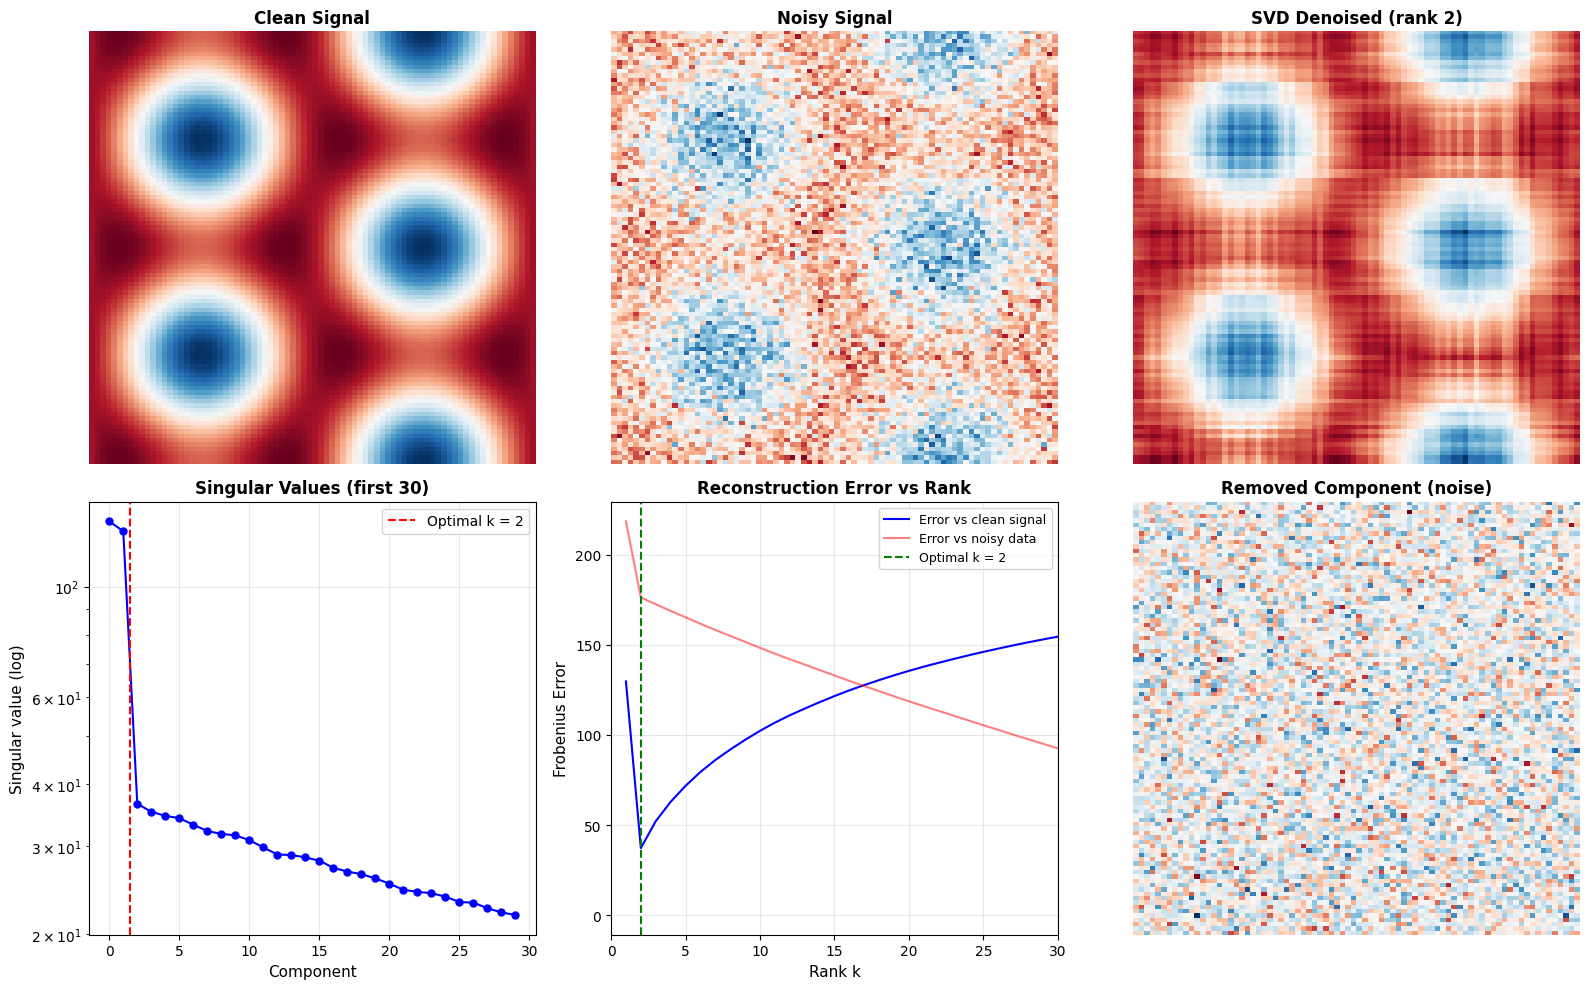

SVD denoising separates signal (kept) from noise (removed).


In [16]:
# SVD Denoising: Separating signal from noise

np.random.seed(42)

# Create a clean signal: smooth 2D pattern
m_d, n_d = 100, 80
t1 = np.linspace(0, 4*np.pi, m_d)
t2 = np.linspace(0, 2*np.pi, n_d)
T1, T2 = np.meshgrid(t2, t1)
signal_clean = 3*np.sin(T1)*np.cos(T2) + 2*np.cos(2*T1)

# Add strong noise
noise_std = 2.0
noise_mat = noise_std * np.random.randn(m_d, n_d)
signal_noisy = signal_clean + noise_mat

# SVD of noisy signal
U_d, S_d, Vt_d = np.linalg.svd(signal_noisy, full_matrices=False)

# Find optimal rank by comparing to clean signal
errors_vs_clean = []
errors_vs_noisy = []
for k in range(1, min(m_d, n_d)+1):
    recon = U_d[:, :k] @ np.diag(S_d[:k]) @ Vt_d[:k, :]
    errors_vs_clean.append(np.linalg.norm(signal_clean - recon, 'fro'))
    errors_vs_noisy.append(np.linalg.norm(signal_noisy - recon, 'fro'))

best_k = np.argmin(errors_vs_clean) + 1
signal_denoised = U_d[:, :best_k] @ np.diag(S_d[:best_k]) @ Vt_d[:best_k, :]

print(f"Clean signal rank: {np.linalg.matrix_rank(signal_clean)}")
print(f"Noisy signal rank: {np.linalg.matrix_rank(signal_noisy)}")
print(f"Optimal rank for denoising: k = {best_k}")
print(f"Error (noisy vs clean):    {np.linalg.norm(noise_mat, 'fro'):.2f}")
print(f"Error (denoised vs clean): {np.linalg.norm(signal_clean - signal_denoised, 'fro'):.2f}")
print(f"Noise reduction: {(1 - np.linalg.norm(signal_clean - signal_denoised, 'fro') / np.linalg.norm(noise_mat, 'fro'))*100:.1f}%")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Top row: images
axes[0,0].imshow(signal_clean, cmap='RdBu_r', aspect='auto')
axes[0,0].set_title('Clean Signal', fontsize=12, fontweight='bold')
axes[0,0].axis('off')

axes[0,1].imshow(signal_noisy, cmap='RdBu_r', aspect='auto')
axes[0,1].set_title('Noisy Signal', fontsize=12, fontweight='bold')
axes[0,1].axis('off')

axes[0,2].imshow(signal_denoised, cmap='RdBu_r', aspect='auto')
axes[0,2].set_title(f'SVD Denoised (rank {best_k})', fontsize=12, fontweight='bold')
axes[0,2].axis('off')

# Bottom left: singular values
axes[1,0].semilogy(S_d[:30], 'bo-', markersize=5)
axes[1,0].axvline(best_k-0.5, color='red', linestyle='--', label=f'Optimal k = {best_k}')
axes[1,0].set_xlabel('Component', fontsize=11)
axes[1,0].set_ylabel('Singular value (log)', fontsize=11)
axes[1,0].set_title('Singular Values (first 30)', fontsize=12, fontweight='bold')
axes[1,0].legend(fontsize=10)
axes[1,0].grid(True, alpha=0.3)

# Bottom middle: error curves
axes[1,1].plot(range(1, len(errors_vs_clean)+1), errors_vs_clean, 'b-', label='Error vs clean signal')
axes[1,1].plot(range(1, len(errors_vs_noisy)+1), errors_vs_noisy, 'r-', alpha=0.5, label='Error vs noisy data')
axes[1,1].axvline(best_k, color='green', linestyle='--', label=f'Optimal k = {best_k}')
axes[1,1].set_xlabel('Rank k', fontsize=11)
axes[1,1].set_ylabel('Frobenius Error', fontsize=11)
axes[1,1].set_title('Reconstruction Error vs Rank', fontsize=12, fontweight='bold')
axes[1,1].legend(fontsize=9)
axes[1,1].set_xlim(0, 30)
axes[1,1].grid(True, alpha=0.3)

# Bottom right: residual (what was removed)
residual = signal_noisy - signal_denoised
axes[1,2].imshow(residual, cmap='RdBu_r', aspect='auto')
axes[1,2].set_title('Removed Component (noise)', fontsize=12, fontweight='bold')
axes[1,2].axis('off')

plt.tight_layout()
plt.show()
print("SVD denoising separates signal (kept) from noise (removed).")

**SVD Denoising -- How It Works**


We created a smooth signal (rank 2), contaminated it with strong random noise, then used SVD to recover the clean signal.

Top row: The clean signal (left) has smooth, structured patterns. The noisy signal (middle) is visibly corrupted. The SVD-denoised version (right, rank
) recovers the smooth structure remarkably well, achieving 79.4% noise reduction.

Bottom left (singular values): The first few singular values are large -- they capture the smooth signal patterns. Then there is a clear drop-off, followed by a plateau of smaller, similar-valued components -- these correspond to noise. The red line marks the optimal cutoff.

Bottom middle (error curves): The blue curve shows error vs. the clean signal. It decreases as we add signal components (rank
 to
), reaches a minimum at the optimal rank, then increases as we start adding noise components. The red curve (error vs. noisy data) monotonically decreases because adding more components always makes the reconstruction closer to the noisy data.

Bottom right (residual): What was removed looks like random noise -- exactly what we wanted to remove. If the residual contained visible patterns, it would mean we removed too much signal.

The denoising principle: Signal has low-rank structure (smooth patterns that can be described by a few basis vectors). Noise is high-rank (random, requiring many components to describe). By keeping only the low-rank components, we separate signal from noise.